Primeras filas:
         Date Store ID Product ID     Category Region  Inventory Level  \
0  2022-01-01     S001      P0001    Groceries  North              231   
1  2022-01-01     S001      P0002         Toys  South              204   
2  2022-01-01     S001      P0003         Toys   West              102   
3  2022-01-01     S001      P0004         Toys  North              469   
4  2022-01-01     S001      P0005  Electronics   East              166   

   Units Sold  Units Ordered  Demand Forecast  Price  Discount  \
0         127             55           135.47  33.50        20   
1         150             66           144.04  63.01        20   
2          65             51            74.02  27.99        10   
3          61            164            62.18  32.72        10   
4          14            135             9.26  73.64         0   

  Weather Condition  Holiday/Promotion  Competitor Pricing Seasonality  
0             Rainy                  0               29.69      Autum

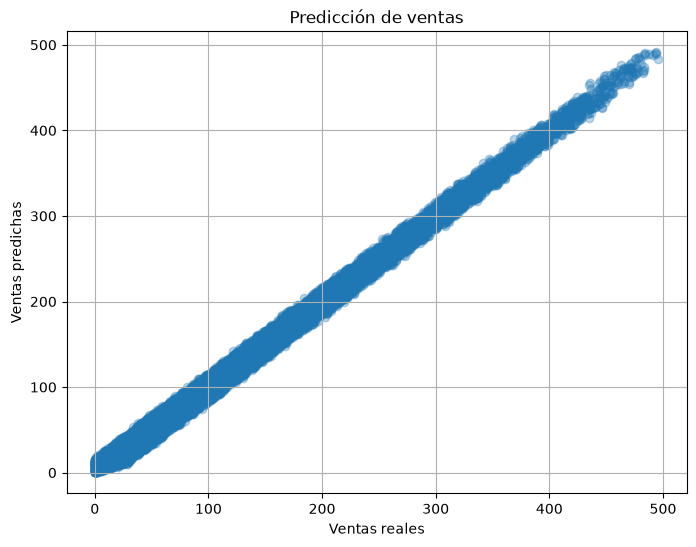


Variables más importantes:
remainder__Demand Forecast               0.994916
remainder__Inventory Level               0.001096
remainder__Units Ordered                 0.000841
remainder__Price                         0.000668
remainder__Competitor Pricing            0.000663
remainder__Discount                      0.000294
remainder__Holiday/Promotion             0.000107
categoricas__Weather Condition_Rainy     0.000085
categoricas__Seasonality_Winter          0.000085
categoricas__Weather Condition_Cloudy    0.000084
dtype: float64

Modelo guardado correctamente.


In [10]:
# =====================================================
# MODELO DE PREDICCIÓN DE VENTAS
# =====================================================

# =====================================================
# 1. IMPORTAR LIBRERÍAS
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# =====================================================
# 2. CARGAR LOS DATOS
# =====================================================

df = pd.read_csv("retail_store_inventory.csv")

print("Primeras filas:")
print(df.head())

print("\nInformación del dataset:")
print(df.info())


# =====================================================
# 3. ELIMINAR COLUMNAS QUE NO USAREMOS
# =====================================================

# Store ID y Product ID son identificadores.
# Date podría usarse más adelante, pero por ahora
# no será necesaria.

df = df.drop(
    columns=[
        "Date",
        "Store ID",
        "Product ID"
    ]
)


# =====================================================
# 4. VARIABLE OBJETIVO
# =====================================================

# Queremos predecir las ventas.

y = df["Units Sold"]


# =====================================================
# 5. VARIABLES DE ENTRADA
# =====================================================

X = df.drop(columns=["Units Sold"])


# =====================================================
# 6. VARIABLES CATEGÓRICAS
# =====================================================

categoricas = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]


# =====================================================
# 7. PREPROCESAMIENTO
# =====================================================

# Convierte texto en variables numéricas.

preprocesador = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            categoricas
        )
    ],
    remainder="passthrough"
)


# =====================================================
# 8. CREAR EL MODELO
# =====================================================

modelo = Pipeline([
    (
        "preprocesamiento",
        preprocesador
    ),

    (
        "random_forest",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])


# =====================================================
# 9. DIVIDIR LOS DATOS
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# =====================================================
# 10. ENTRENAR EL MODELO
# =====================================================

modelo.fit(X_train, y_train)

print("\nModelo entrenado correctamente.")


# =====================================================
# 11. REALIZAR PREDICCIONES
# =====================================================

predicciones = modelo.predict(X_test)


# =====================================================
# 12. EVALUAR EL MODELO
# =====================================================

mae = mean_absolute_error(
    y_test,
    predicciones
)

r2 = r2_score(
    y_test,
    predicciones
)

print("\nResultados del modelo:")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")


# =====================================================
# 13. GRÁFICO DE RESULTADOS
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predicciones,
    alpha=0.3
)

plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Predicción de ventas")

plt.grid(True)

plt.show()


# =====================================================
# 14. IMPORTANCIA DE VARIABLES
# =====================================================

rf = modelo.named_steps["random_forest"]

nombres_columnas = (
    modelo.named_steps["preprocesamiento"]
    .get_feature_names_out()
)

importancias = pd.Series(
    rf.feature_importances_,
    index=nombres_columnas
)

print("\nVariables más importantes:")

print(
    importancias
    .sort_values(ascending=False)
    .head(10)
)


# =====================================================
# 15. GUARDAR EL MODELO
# =====================================================

joblib.dump(
    modelo,
    "modelo_ventas.pkl"
)

print("\nModelo guardado correctamente.")

In [12]:
nuevo_producto = pd.DataFrame({

    "Category": ["Groceries"],
    "Region": ["North"],
    "Inventory Level": [120],
    "Units Ordered": [100],
    "Demand Forecast": [130],
    "Price": [45],
    "Discount": [10],
    "Weather Condition": ["Sunny"],
    "Holiday/Promotion": [1],
    "Competitor Pricing": [42],
    "Seasonality": ["Summer"]

})

prediccion = modelo.predict(nuevo_producto)

print(
    f"Ventas estimadas: {prediccion[0]:.0f} unidades"
)

Ventas estimadas: 114 unidades


In [13]:
inventario = 120

if prediccion[0] > inventario:
    print("⚠ Riesgo de quiebre de stock.")
else:
    print("✓ Inventario suficiente.")

✓ Inventario suficiente.
